---
layout: post
title: "Pre_studying"
date: 2023-04-25 14:20:00+0800
chap: level_3
---


# Pre studying

对于`GPT`的入门，`karpathy`在`utube`上，上传了简单的[系列讲解视频][https://www.youtube.com/playlist?list=PLAqhIrjkxbuWI23v9cThsA9GvCAUhRvKZ]，在每个视频中，都在`github`上上传了相应的组件代码，用最简单的代码实现，讲解了关于`bp,Transformer`等概念，每个文件也不过几百行代码，但却实现了`bp`等机器学习中的重要概念，是很好的入门`GPT`的资料，所以想要以此为抓手，快速入门
## Back propagation
将全连接神经网络看作一个函数的话，机器学习首要的目的，就是训练参数，使得输出尽可能地接近预期输出
所以很直观地，就需要一个评估输出之间距离的函数，和一个调节参数的方法，所以以下的展开，对应于这两个概念：
- `loss function`
- `gradient decent`
  - ` back bropagation`

如果对于机器学习来说，已知有参数$\theta$ 
$$
\theta^{n + 1} = \theta ^n - \eta \triangle L(\theta ^n)\\
\eta: learning\ rate
$$
而BP，就是对中间层求导数的一个很好的算法，其目的失球损失函数对权重/偏执参数的导数，基本原理是链式求导法则：
$$
\frac{\partial Y}{\partial w} = \frac{\partial Y}{\partial z}\frac{\partial z}{\partial w}
$$
其中`w`是其中一层，对于其输入`x`的系数，`z`是该层的输出，将$\frac{\partial Y}{\partial w}$记为`w.grad`
因为我们只能得到最终输出的数据，对于中间值，则需要递归式地求得不同层下的`gradient`,再进行调整
而对于该层的输出，所有参与到下一层输入中的`z`，使用链式法则算出的梯度，按照权重叠加起来，即为层最后的`grandient`
$$
\frac{\partial Y}{\partial w} = \sum{x_i \frac{\partial Y}{\partial z}}
$$
对于`w`来说，此时的`x`就是他的权重(省略激活函数)
接下来，实现一个简单的可以实现`BP`的类：

In [47]:
class Value:
    def __init__(self,data, child=(),label = '', grad = 0.0,_op = '') -> None:
        self.data = data
        self.grad = grad
        self._op = _op
        self.prev_ = set(child)
        self._backward = None
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, child=(self, other),label= '+',_op = '+')

        def _backward():
            self.grad += out.grad
            other.grad += out.grad
        out._backward = _backward
    
        return out
    def __sub__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data - other.data, child=(self, other),label= '-',_op = '-')

        def _backward():
            self.grad += out.grad
            other.grad -= out.grad
        out._backward = _backward

        return out
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, child=(self, other),label= '*',_op = '*')

        def _backward():
            self.grad += out.grad * other.data
            other.grad += out.grad * self.data
        out._backward = _backward
        return out
    
    def __div__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data / other.data, child=(self, other),label= '/',_op = '/')

        def _backward():
            self.grad += out.grad / other.data
            other.grad += out.grad * (-self.data / other.data**2) 
        out._backward = _backward
        return out
    
    def __pow__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data ** other.data, child=(self, ),label= '**',_op = '**')

        def _backward():
            self.grad += out.grad * (other.data * self.data**(other.data - 1))
        out._backward = _backward
        return out
    def backward(self):
        topo = [self]
        self.grad = 1.0
        def tran():
            while len(topo) > 0:
                tmp = topo.pop(0)
                for ch in tmp.prev_:
                    topo.append(ch)
                if len(tmp.prev_):
                    tmp._backward()
        tran()
    def relu(self):
        out = Value(0 if self.data < 0 else self.data, (self,), 'ReLU')

        def _backward():
            self.grad += (out.data > 0) * out.grad
        out._backward = _backward

        return out
    
    def __neg__(self):
        return self * -1
    def __radd__(self,other):
        return self + other
    def __rdiv__(self, other):
        return self / other
    def __rmul__(self, other):
        return self * other
    
    def __rsub__(self,other):
        return self - other
    
    

简单地测试一下，上述的代码实现，同样的，采取的是`karpathy`使用的画类流程图的方式：

2386226972360


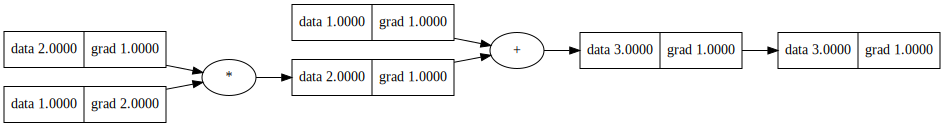

In [48]:
from graphviz import Digraph
def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v.prev_:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    assert rankdir in ['LR', 'TB']
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir}) #, node_attr={'rankdir': 'TB'})
    
    for n in nodes:
        dot.node(name=str(id(n)), label = "{ data %.4f | grad %.4f }" % (n.data, n.grad), shape='record')
        if n._op:
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))
    
    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

x = Value(1.0)
y = (x * 2 + 1).relu()
# print(y) 
y.backward()
print(str(id(x)))
draw_dot(y)

基于此，尝试构造多层的神经网络：

In [49]:
import random

class Module:
    def zero_grad(self):
        for p in self.parameters():
            p.grad = 0
    def parameters(self):
        return []
    
class Neuron(Module):
    def __init__(self,nin,nonline = True) -> None:
        super().__init__()
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(0)
        self.noline = nonline
    def __call__(self, x) :
        act = sum((wi * xi for wi,xi in zip(self.w,x)),self.b) 
        return act.relu() if self.noline else act
    def parameters(self):
        return self.w + [self.b]
    def __repr__(self) -> str:
        return f"{'ReLU' if self.noline else 'Linear'}Neuron ({len(self.w)})"
class Layer(Module):
    def __init__(self,nin,nout,**kwargs) -> None:
        self.nerons = [Neuron(nin, **kwargs) for _ in range(nout)]
    def __call__(self, x):
        out = [n(x) for n in self.nerons]

        return out[0] if len(out) == 1 else out
    def parameters(self):
        return [p for n in self.nerons for p in n.parameters()]
    def __repr__(self) -> str:
        return f"Layer of [{', '.join(str(n) for n in self.nerons)}]"
class MLP(Module):
    def __init__(self,nins,nouts):
        # print(nins,nouts)
        sz = nins+[nouts]
        self.layers = [Layer(sz[i],sz[i + 1],nonline = i!=(len(nins) - 1)) for i in range(len(nins))]
    
    def __call__(self,x):
        for l in self.layers:
            x = l(x)
        return x
    def parameters(self):  
        return [p for l in self.layers for p in l.parameters()]
    def __repr__(self) -> str:
        return f"MLP of [{', '.join(str(l)for l in self.layers)}]"
    

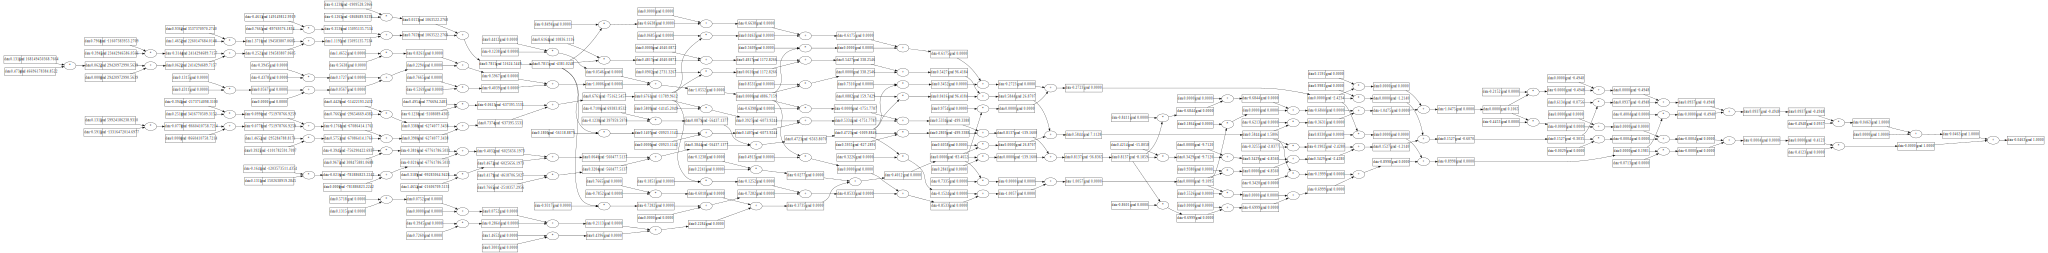

In [50]:
nins = [i + 2 for i in range(5)]
nouts = 1
mlp_test = MLP(list(reversed(nins)),nouts)
x_in = [random.uniform(-2,2) for _ in range(5)]
y_out = mlp_test(x_in)
y_out.backward()
draw_dot(y_out)


在得到这样一个简单的全连接网络之后，以`NLP`的模型为例，尝试搭建简单的模型，尝试构造损失函数，并对参数进行训练
## Bigram